# 1. Problem Statement

Financial institutions receive thousands of loan applications every day. Evaluating each application manually is time-consuming and may lead to inconsistent decisions. Banks need an intelligent system that can analyze an applicant’s financial and personal information and predict whether the loan should be approved.

The goal of this project is to build a machine learning model that predicts the loan approval status based on applicant details such as income, education, credit history, employment status, and property area.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Loan_prediction_dataset.csv")

In [6]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


# understand the dataset

In [7]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
df.shape

(614, 13)

In [9]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [11]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# Data Cleaning

In [12]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

# Numerical Columns
- ApplicantIncome
- CoapplicantIncome
- LoanAmount
- Loan_Amount_Term

# Categorical Columns
- Gender
- Married
- Dependents
- Education
- Self_Employed
- Credit History
- Property Areas

# Target column
- Loan_Status


In [13]:
# Cleaning Numerical Columns
df["ApplicantIncome"].isnull().sum()

np.int64(0)

In [14]:
df["CoapplicantIncome"].isnull().sum()

np.int64(0)

In [15]:
df["LoanAmount"].isnull().sum()

np.int64(22)

<Axes: ylabel='LoanAmount'>

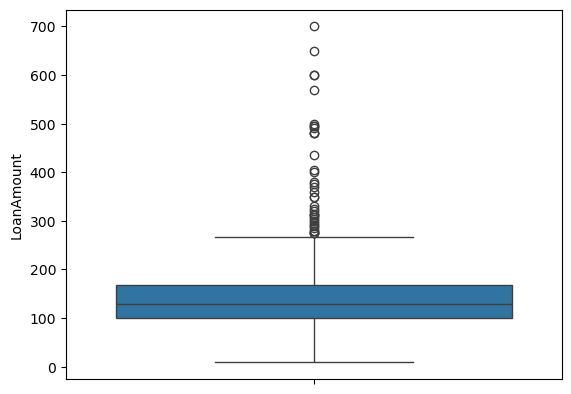

In [16]:
#check for outliers

sns.boxplot(df["LoanAmount"])

<Axes: xlabel='CoapplicantIncome', ylabel='Count'>

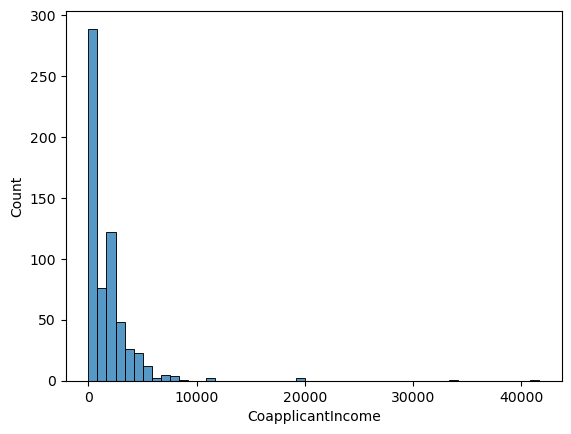

In [17]:
# type of data distribution

sns.histplot(df["CoapplicantIncome"])

In [18]:
# replace null values by median (Skewed distbn + Ouliers are present)

median=df["LoanAmount"].median()
df["LoanAmount"]=df["LoanAmount"].fillna(median)

In [19]:
df["Loan_Amount_Term"].isnull().sum()

np.int64(14)

<Axes: ylabel='Loan_Amount_Term'>

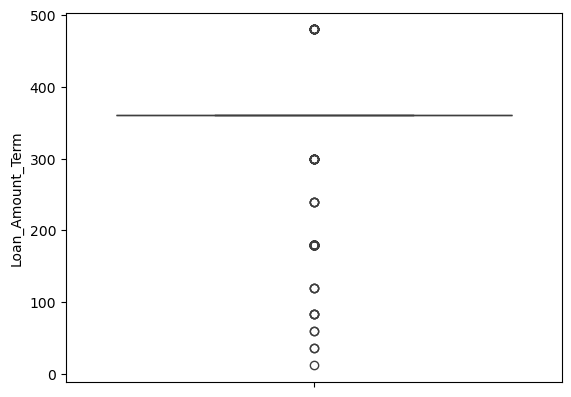

In [20]:
# check outliers

sns.boxplot(df["Loan_Amount_Term"])

<Axes: xlabel='Loan_Amount_Term', ylabel='Count'>

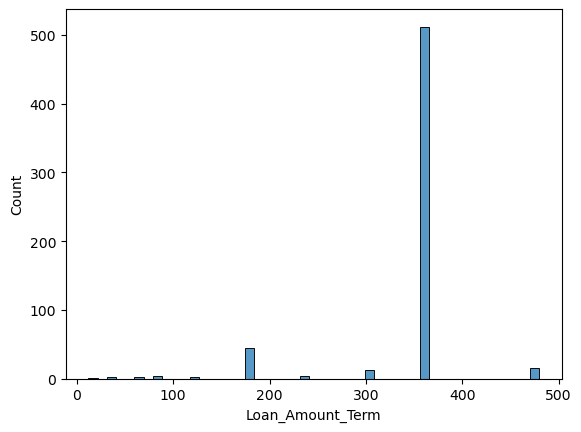

In [21]:
#check distribution
sns.histplot(df["Loan_Amount_Term"])

In [22]:
# Filling null values with median

median=df["Loan_Amount_Term"].median()
df["Loan_Amount_Term"]=df["Loan_Amount_Term"].fillna(median)

In [23]:
df["Gender"].isnull().sum()

np.int64(13)

<Axes: xlabel='Gender', ylabel='count'>

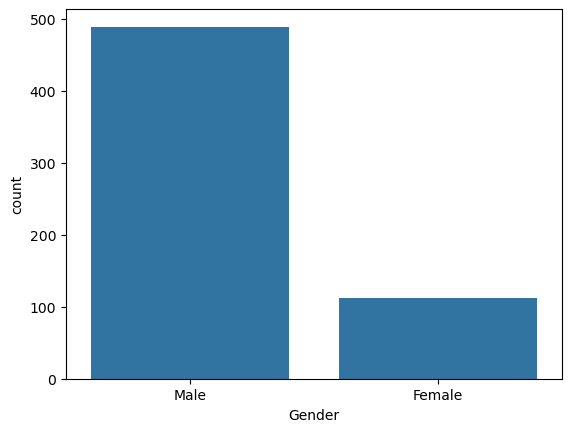

In [24]:
# checking which gender is applying more so we can replace null values with them
sns.countplot(x=df["Gender"])

In [25]:
# filling null using mode
mode=df["Gender"].mode()
df["Gender"]=df["Gender"].fillna(mode[0])

In [26]:
df["Married"].isnull().sum()

np.int64(3)

<Axes: xlabel='Married', ylabel='count'>

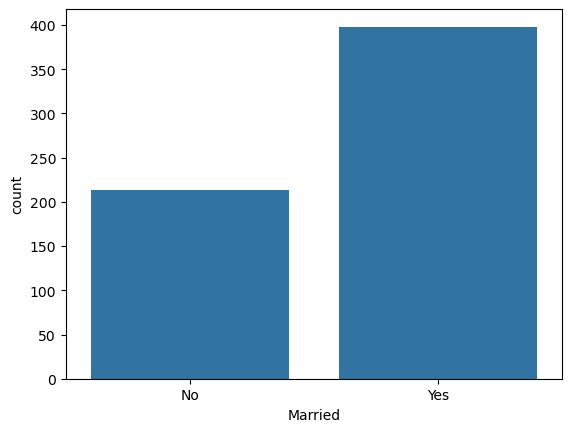

In [27]:
# checking frequency count
sns.countplot(x=df["Married"])

In [28]:
# filling null values with most frequent one
mode=df["Married"].mode()
df["Married"]=df["Married"].fillna(mode[0])

In [29]:
df["Dependents"].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

<Axes: xlabel='Dependents', ylabel='count'>

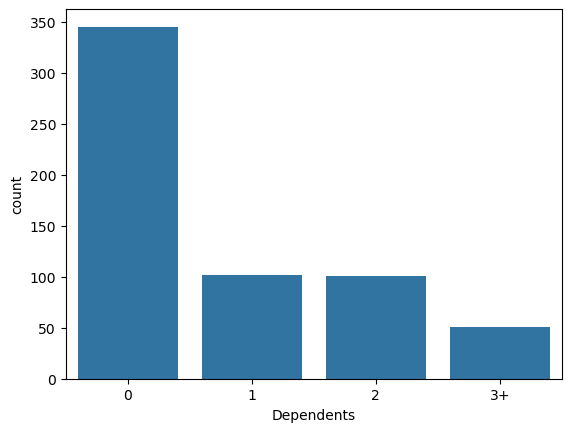

In [30]:
# checking frequency

sns.countplot(x=df["Dependents"])

In [31]:
# filling null values with most frequent

mode=df["Dependents"].mode()
df["Dependents"]=df["Dependents"].fillna(mode[0])

In [32]:
df["Education"].isnull().sum()

np.int64(0)

In [33]:
print(type(df["Self_Employed"][0]))
df["Self_Employed"].isnull().sum()

<class 'str'>


np.int64(32)

<Axes: xlabel='Self_Employed', ylabel='count'>

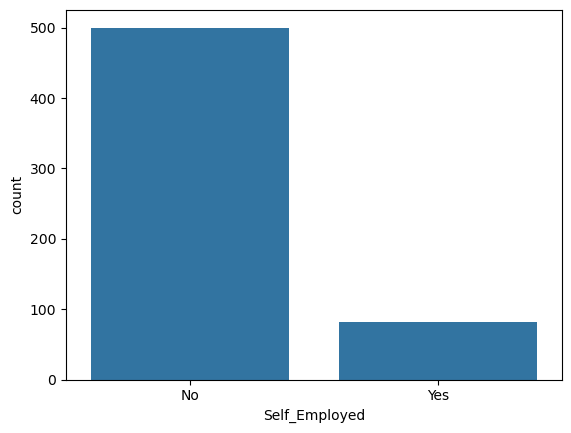

In [34]:
# checking frequency

sns.countplot(x=df["Self_Employed"])

In [35]:
mode=df["Self_Employed"].mode()
df["Self_Employed"]=df["Self_Employed"].fillna(mode[0])

In [36]:
df["Self_Employed"].value_counts()

Self_Employed
No     532
Yes     82
Name: count, dtype: int64

In [37]:
mode=df["Credit_History"].mode()

In [38]:
df["Credit_History"].fillna(mode[0],inplace=True)

/var/folders/jl/_dqc9shj5bqdgzm1f58n0csw0000gn/T/ipykernel_1110/3738562738.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Credit_History"].fillna(mode[0],inplace=True)


In [39]:
# changing data type form float to int 

df["Credit_History"]=df["Credit_History"].astype(int)

<Axes: xlabel='Property_Area', ylabel='count'>

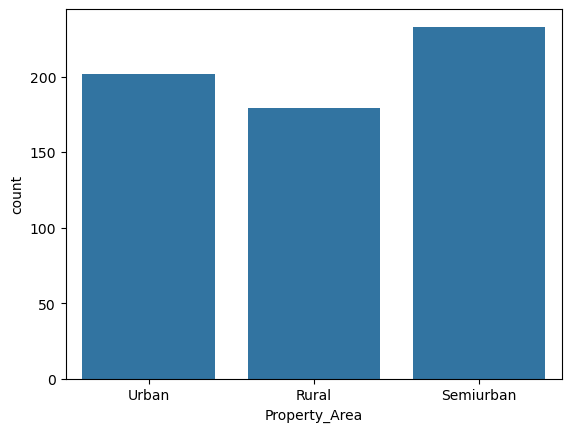

In [40]:
# checking frequency

sns.countplot(x=df["Property_Area"])

In [41]:
# filling null values with most frequent one

df["Property_Area"]=df["Property_Area"].fillna(mode[0])


# Analysing columns and finding relationships

In [42]:
print(df.columns.to_list())

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [43]:
df["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

Finding relationship between gender and loan status column

In [44]:

df.groupby(["Gender","Loan_Status"]).size().unstack()
female_yes=len(df[(df["Loan_Status"]=="Y") & (df["Gender"]=="Female")])
male_yes=len(df[(df["Loan_Status"]=="Y") & (df["Gender"]=="Male")])
total_yes=len(df[df["Loan_Status"]=="Y"])

In [45]:
male_percent=(male_yes/total_yes)*100
female_percent=(female_yes/total_yes)*100

print("Accepting Male Loan Requests:",male_percent)
print("Accepting Female Loan Requests:",female_percent)

Accepting Male Loan Requests: 82.22748815165876
Accepting Female Loan Requests: 17.77251184834123


# <h3>-The Loan accepting percent for male is high

In [46]:
(df.groupby(["Married", "Loan_Status"])
   .size()
   .unstack()
   .apply(lambda x: x / x.sum() * 100, axis=1))

Loan_Status,N,Y
Married,,
No,37.089202,62.910798
Yes,28.179551,71.820449


# <h3>- Both The married and unmarried are getting accepted but married ones with little high advantage

In [47]:
df.groupby(["Dependents","Loan_Status"]).size().unstack().apply(
    lambda x:(x/x.sum())*100 , axis=1
)

Loan_Status,N,Y
Dependents,,
0,31.388889,68.611111
1,35.294118,64.705882
2,24.752475,75.247525
3+,35.294118,64.705882


# <h3> - Dependent column is also not affecting loan status much  

In [48]:
df.groupby(["Education","Loan_Status"]).size().unstack().apply(
    lambda x:(x/x.sum())*100,axis=1
)

Loan_Status,N,Y
Education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


# <h3> - Education columns is also not impacting more

In [49]:
df.groupby(["Self_Employed","Loan_Status"]).size().unstack().apply(
    lambda x:(x/x.sum())*100 , axis=1
)

Loan_Status,N,Y
Self_Employed,,
No,31.203008,68.796992
Yes,31.707317,68.292683


# <h3> -Self employed column is also not impacting more

In [50]:
numerical_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

for col in numerical_cols:
    print(f"\n{col}")
    print(df.groupby("Loan_Status")[col].mean())


ApplicantIncome
Loan_Status
N    5446.078125
Y    5384.068720
Name: ApplicantIncome, dtype: float64

CoapplicantIncome
Loan_Status
N    1877.807292
Y    1504.516398
Name: CoapplicantIncome, dtype: float64

LoanAmount
Loan_Status
N    149.890625
Y    143.869668
Name: LoanAmount, dtype: float64

Loan_Amount_Term
Loan_Status
N    344.56250
Y    341.43128
Name: Loan_Amount_Term, dtype: float64


In [51]:
pd.crosstab(df["Credit_History"], df["Loan_Status"], normalize="index") * 100

Loan_Status,N,Y
Credit_History,,
0,92.134831,7.865169
1,20.952381,79.047619


# <h3> - Applicants with credit history can get more approval for loans

# Feature Engineering 

In [52]:
df["TotalIncome"] = (
    df["ApplicantIncome"] +
    df["CoapplicantIncome"]
)

In [53]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,Y,6000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1,Rural,Y,2900.0
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1,Rural,Y,4106.0
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1,Urban,Y,8312.0
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1,Urban,Y,7583.0


In [54]:
df["LoanIncomeRatio"] = (
    df["LoanAmount"] /
    df["TotalIncome"]
)

In [55]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanIncomeRatio
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1,Urban,Y,5849.0,0.021884
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,N,6091.0,0.021015
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,Y,3000.0,0.022000
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,Y,4941.0,0.024287
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,Y,6000.0,0.023500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1,Rural,Y,2900.0,0.024483
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1,Rural,Y,4106.0,0.009742
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1,Urban,Y,8312.0,0.030438
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1,Urban,Y,7583.0,0.024660


In [56]:
print(df.groupby("Loan_Status")["TotalIncome"].mean())
print(df.groupby("Loan_Status")["LoanIncomeRatio"].mean())

Loan_Status
N    7323.885417
Y    6888.585118
Name: TotalIncome, dtype: float64
Loan_Status
N    0.024988
Y    0.023371
Name: LoanIncomeRatio, dtype: float64


In [57]:
df.drop("Loan_ID",axis=1,inplace=True)

# Converting Categorical columns to Numerical columns

In [58]:
def gender(x):
    if x=="Male":
        return 1
    else:
        return 0
    
def Married(x):
    if x=="No":
        return 0
    else:
        return 1

def Education(x):
    if x=="Graduate":
        return 1
    else:
        return 0
    
def employed(x):
    if x=="Yes":
        return 1
    else:
        return 0
    
def status(x):
    if x=="Y":
        return 1
    else:
        return 0

# Binary Encoding

In [59]:
df["Gender"]=df["Gender"].apply(gender)
df["Married"]=df["Married"].apply(Married)
df["Education"]=df["Education"].apply(Education)
df["Self_Employed"]=df["Self_Employed"].apply(employed)
df["Loan_Status"]=df["Loan_Status"].apply(status)

In [60]:
df["Dependents"] = df["Dependents"].replace("3+", 3)
df["Dependents"] = df["Dependents"].astype(int)

In [61]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanIncomeRatio
0,1,0,0,1,0,5849,0.0,128.0,360.0,1,Urban,1,5849.0,0.021884
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1,Rural,0,6091.0,0.021015
2,1,1,0,1,1,3000,0.0,66.0,360.0,1,Urban,1,3000.0,0.022000
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1,Urban,1,4941.0,0.024287
4,1,0,0,1,0,6000,0.0,141.0,360.0,1,Urban,1,6000.0,0.023500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,1,0,2900,0.0,71.0,360.0,1,Rural,1,2900.0,0.024483
610,1,1,3,1,0,4106,0.0,40.0,180.0,1,Rural,1,4106.0,0.009742
611,1,1,1,1,0,8072,240.0,253.0,360.0,1,Urban,1,8312.0,0.030438
612,1,1,2,1,0,7583,0.0,187.0,360.0,1,Urban,1,7583.0,0.024660


# One Hot Encoding

In [62]:
df = pd.get_dummies(
    df,
    columns=["Property_Area"],
    drop_first=True
)

In [63]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'TotalIncome',
       'LoanIncomeRatio', 'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='object')

In [64]:
numerical_cols

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

In [65]:

dummy_cols = ["Property_Area_Semiurban", "Property_Area_Urban"]

df[dummy_cols] = df[dummy_cols].astype(int)

In [66]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,LoanIncomeRatio,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1,1,5849.0,0.021884,0,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1,0,6091.0,0.021015,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1,1,3000.0,0.022000,0,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1,1,4941.0,0.024287,0,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1,1,6000.0,0.023500,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,1,0,2900,0.0,71.0,360.0,1,1,2900.0,0.024483,0,0
610,1,1,3,1,0,4106,0.0,40.0,180.0,1,1,4106.0,0.009742,0,0
611,1,1,1,1,0,8072,240.0,253.0,360.0,1,1,8312.0,0.030438,0,1
612,1,1,2,1,0,7583,0.0,187.0,360.0,1,1,7583.0,0.024660,0,1


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    int64  
 1   Married                  614 non-null    int64  
 2   Dependents               614 non-null    int64  
 3   Education                614 non-null    int64  
 4   Self_Employed            614 non-null    int64  
 5   ApplicantIncome          614 non-null    int64  
 6   CoapplicantIncome        614 non-null    float64
 7   LoanAmount               614 non-null    float64
 8   Loan_Amount_Term         614 non-null    float64
 9   Credit_History           614 non-null    int64  
 10  Loan_Status              614 non-null    int64  
 11  TotalIncome              614 non-null    float64
 12  LoanIncomeRatio          614 non-null    float64
 13  Property_Area_Semiurban  614 non-null    int64  
 14  Property_Area_Urban      6

In [68]:
df.isnull().sum()

Gender                     0
Married                    0
Dependents                 0
Education                  0
Self_Employed              0
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
Loan_Status                0
TotalIncome                0
LoanIncomeRatio            0
Property_Area_Semiurban    0
Property_Area_Urban        0
dtype: int64

In [69]:
df["ApplicantIncome"] = np.log1p(df["ApplicantIncome"])
df["CoapplicantIncome"] = np.log1p(df["CoapplicantIncome"])
df["LoanAmount"] = np.log1p(df["LoanAmount"])
df["TotalIncome"] = np.log1p(df["TotalIncome"])

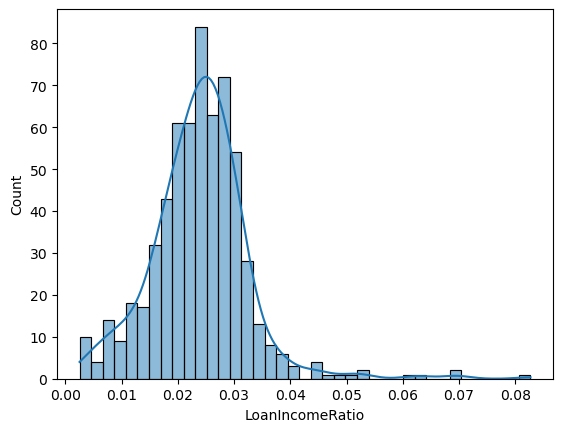

In [70]:
sns.histplot(df["LoanIncomeRatio"], kde=True)
plt.show()

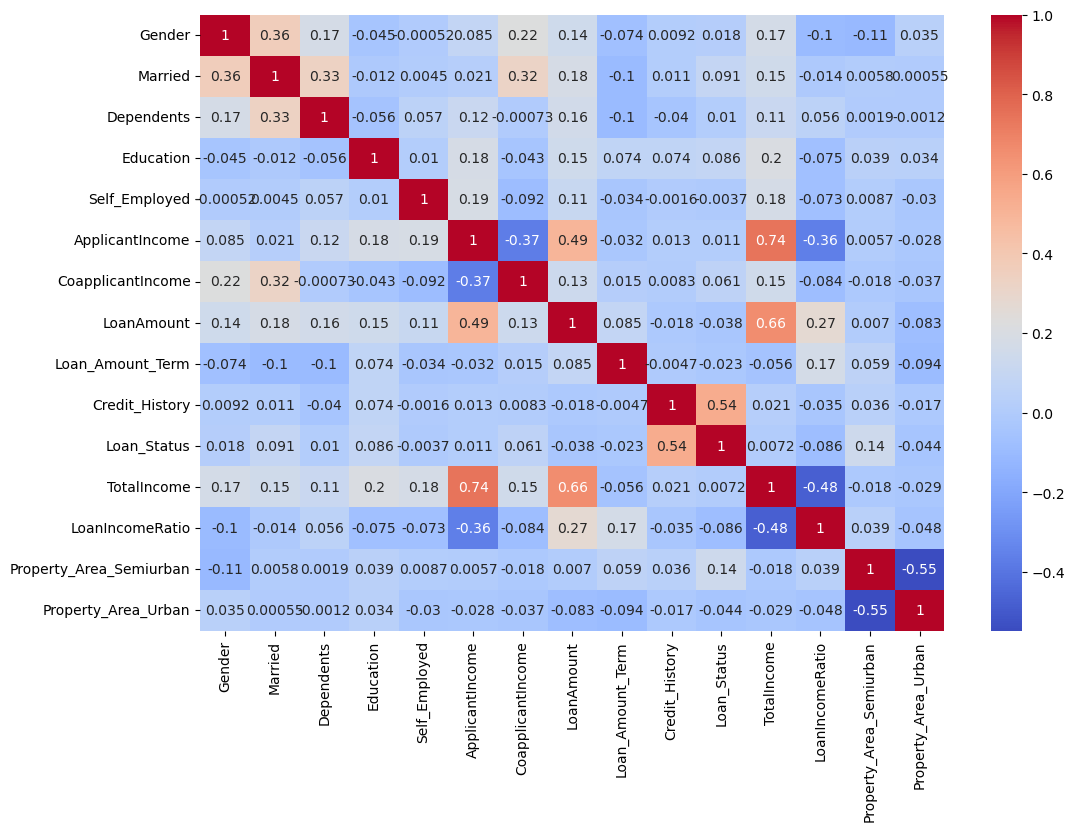

In [71]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [72]:
x=df.drop("Loan_Status",axis=1)
y=df["Loan_Status"]

In [73]:
x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,LoanIncomeRatio,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,8.674197,0.000000,4.859812,360.0,1,8.674197,0.021884,0,1
1,1,1,1,1,0,8.430327,7.319202,4.859812,360.0,1,8.714732,0.021015,0,0
2,1,1,0,1,1,8.006701,0.000000,4.204693,360.0,1,8.006701,0.022000,0,1
3,1,1,0,0,0,7.857094,7.765993,4.795791,360.0,1,8.505525,0.024287,0,1
4,1,0,0,1,0,8.699681,0.000000,4.955827,360.0,1,8.699681,0.023500,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,1,0,7.972811,0.000000,4.276666,360.0,1,7.972811,0.024483,0,0
610,1,1,3,1,0,8.320448,0.000000,3.713572,180.0,1,8.320448,0.009742,0,0
611,1,1,1,1,0,8.996280,5.484797,5.537334,360.0,1,9.025576,0.030438,0,1
612,1,1,2,1,0,8.933796,0.000000,5.236442,360.0,1,8.933796,0.024660,0,1


In [74]:
y

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64

In [75]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=1)

In [76]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [77]:
xtrain_scaled=scaler.fit_transform(xtrain)
xtest_scaled=scaler.transform(xtest)

In [78]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(random_state=42)

model.fit(xtrain_scaled,ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [79]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

In [80]:
ypred=model.predict(xtest_scaled)
logistic_accuracy=accuracy_score(ytest,ypred)
logistic_precision=precision_score(ytest,ypred)
logistic_recall=recall_score(ytest,ypred)
logistic_f1=f1_score(ytest,ypred)
logistic_roc=roc_auc_score(ytest,ypred)

In [81]:
from sklearn.svm import SVC
model=SVC()
model.fit(xtrain_scaled,ytrain)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [82]:
ypred=model.predict(xtest_scaled)
svm_accuracy=accuracy_score(ytest,ypred)
svm_precision=precision_score(ytest,ypred)
svm_recall=recall_score(ytest,ypred)
svm_f1=f1_score(ytest,ypred)
svm_roc=roc_auc_score(ytest,ypred)

In [83]:

import math
from sklearn.neighbors import KNeighborsClassifier
k=int(math.sqrt(len(xtest)))
model=KNeighborsClassifier(n_neighbors=k)
model.fit(xtrain_scaled,ytrain)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [84]:
ypred=model.predict(xtest_scaled)
knn_accuracy=accuracy_score(ytest,ypred)
knn_precision=precision_score(ytest,ypred)
knn_recall=recall_score(ytest,ypred)
knn_f1=f1_score(ytest,ypred)
knn_roc=roc_auc_score(ytest,ypred)

In [85]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(xtrain,ytrain)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [86]:
ypred=model.predict(xtest)
dtc_accuracy=accuracy_score(ytest,ypred)
dtc_precision=precision_score(ytest,ypred)
dtc_recall=recall_score(ytest,ypred)
dtc_f1=f1_score(ytest,ypred)
dtc_roc=roc_auc_score(ytest,ypred)

In [87]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=25)
model.fit(xtrain,ytrain)

,n_estimators,25
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [88]:
ypred=model.predict(xtest)
rfc_accuracy=accuracy_score(ytest,ypred)
rfc_precision=precision_score(ytest,ypred)
rfc_recall=recall_score(ytest,ypred)
rfc_f1=f1_score(ytest,ypred)
rfc_roc=roc_auc_score(ytest,ypred)

In [89]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(xtrain,ytrain)

,priors,None
,var_smoothing,1e-09


In [90]:
ypred=model.predict(xtest)
gnb_accuracy=accuracy_score(ytest,ypred)
gnb_precision=precision_score(ytest,ypred)
gnb_recall=recall_score(ytest,ypred)
gnb_f1=f1_score(ytest,ypred)
gnb_roc=roc_auc_score(ytest,ypred)

In [91]:
d={"model":["LogisticRegression","KNN","SVM","DecisionTree","RandomForest","GaussianNaiveBayes"],"accuracy":[logistic_accuracy,knn_accuracy,svm_accuracy,dtc_accuracy,rfc_accuracy,gnb_accuracy],"precision_score":[logistic_precision,knn_precision,svm_precision,dtc_precision,rfc_precision,gnb_precision],"recall":[logistic_recall,knn_recall,svm_recall,dtc_recall,rfc_recall,gnb_recall],"f1_score":[logistic_f1,knn_f1,svm_f1,dtc_f1,rfc_f1,gnb_f1],"roc_auc_score":[logistic_roc,knn_roc,svm_roc,dtc_roc,rfc_roc,gnb_roc]}
result=pd.DataFrame(d)

In [92]:
result

,model,accuracy,precision_score,recall,f1_score,roc_auc_score
0,LogisticRegression,0.804878,0.783019,0.988095,0.873684,0.699176
1,KNN,0.772358,0.754545,0.988095,0.855670,0.647894
2,SVM,0.804878,0.783019,0.988095,0.873684,0.699176
3,DecisionTree,0.723577,0.790698,0.809524,0.800000,0.673993
4,RandomForest,0.813008,0.808081,0.952381,0.874317,0.732601
5,GaussianNaiveBayes,0.804878,0.788462,0.976190,0.872340,0.706044


In [93]:
result.sort_values(by="accuracy", ascending=False)

,model,accuracy,precision_score,recall,f1_score,roc_auc_score
4,RandomForest,0.813008,0.808081,0.952381,0.874317,0.732601
0,LogisticRegression,0.804878,0.783019,0.988095,0.873684,0.699176
2,SVM,0.804878,0.783019,0.988095,0.873684,0.699176
5,GaussianNaiveBayes,0.804878,0.788462,0.976190,0.872340,0.706044
1,KNN,0.772358,0.754545,0.988095,0.855670,0.647894
3,DecisionTree,0.723577,0.790698,0.809524,0.800000,0.673993


In [94]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid = GridSearchCV(
    LogisticRegression(),
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(xtrain_scaled, ytrain)

print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
0.8167594310451454


In [95]:
from sklearn.ensemble import RandomForestClassifier

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(xtrain, ytrain)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
0.8208616780045352


In [96]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=1,
    random_state=42
)

best_rf.fit(xtrain, ytrain)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [97]:
ypred = best_rf.predict(xtest)

In [98]:
accuracy=accuracy_score(ytest,ypred)

precision=precision_score(ytest,ypred)

recall=recall_score(ytest,ypred)

f1=f1_score(ytest,ypred)

roc=roc_auc_score(ytest,ypred)
from sklearn.metrics import classification_report
report=classification_report(ytest,ypred)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(ytest, ypred)
print(cm)

[[19 20]
 [ 2 82]]


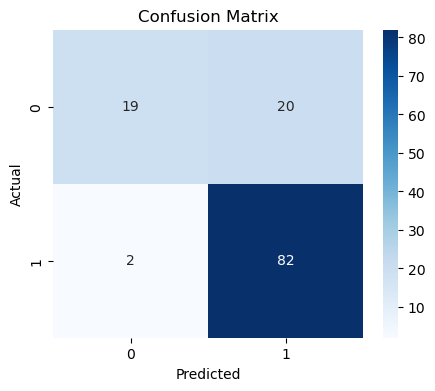

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(ytest, ypred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [100]:
importance = pd.DataFrame({
    "Feature": xtrain.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
9,Credit_History,0.394854
11,LoanIncomeRatio,0.122381
10,TotalIncome,0.100862
5,ApplicantIncome,0.097439
7,LoanAmount,0.074022
6,CoapplicantIncome,0.066839
8,Loan_Amount_Term,0.039482
2,Dependents,0.024258
12,Property_Area_Semiurban,0.023184
1,Married,0.014260


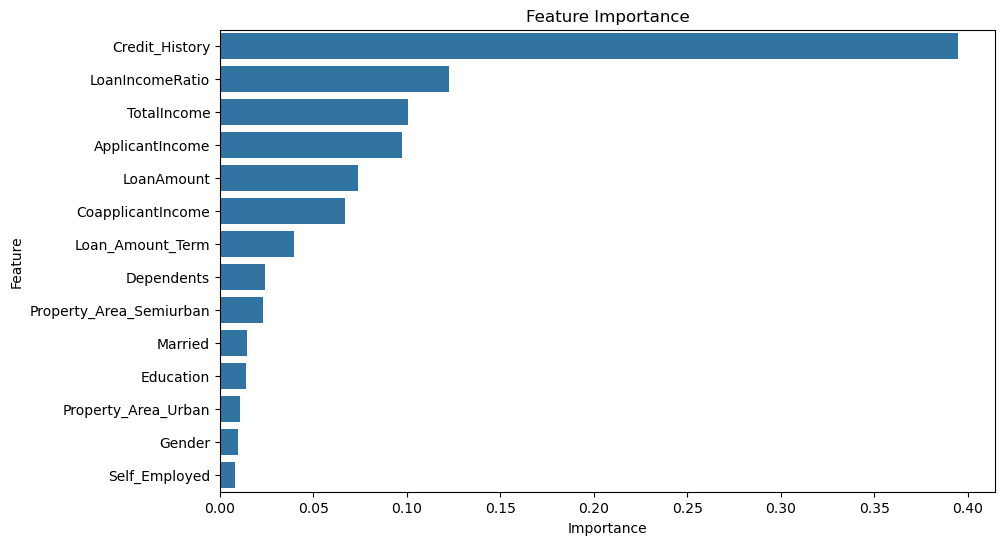

In [101]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [102]:
import joblib
joblib.dump(best_rf,"best_rf.pkl")

['best_rf.pkl']

In [103]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [104]:
xtest.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'LoanIncomeRatio',
       'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='object')